In [ ]:
from google.colab import files
import io

uploaded = files.upload()

for filename in uploaded.keys():
  print(f'Uploaded file: {filename}')
  # To read the content of the file:
  # content = uploaded[filename].decode('utf-8')
  # print(f'File content (first 100 chars):\n{content[:100]}')
  # You can then process the content further, e.g., save it to a variable or to disk


Saving AmazonFood_Reviews.csv to AmazonFood_Reviews.csv
Uploaded file: AmazonFood_Reviews.csv


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming the filename was 'AmazonFood_Reviews.csv' from the upload
# Read the content from the 'uploaded' dictionary
for filename_uploaded, file_content in uploaded.items():
    df = pd.read_csv(io.BytesIO(file_content))
    print(f"Successfully loaded '{filename_uploaded}' into DataFrame.")
    break # Assuming only one file was uploaded

# Display the first few rows and information about the DataFrame
display(df.head())
print("\nDataFrame Info:")
df.info()

# Drop rows with missing 'Text' or 'Score'
df.dropna(subset=['Text', 'Score'], inplace=True)
print(f"\nDataFrame shape after dropping NaNs: {df.shape}")

# Convert scores to a 0-indexed categorical format if needed, or keep as is for regression/ordinal classification
# For simplicity, let's treat 1-5 as 0-4 for categorical output
df['Score'] = df['Score'] - 1 # Scores are 1-5, convert to 0-4

# Check the distribution of scores
print("\nScore distribution:")
print(df['Score'].value_counts())

# Prepare data for GRU
X = df['Text'].values
y = df['Score'].values

Successfully loaded 'AmazonFood_Reviews.csv' into DataFrame.


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...



DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568454 entries, 0 to 568453
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   Id                      568454 non-null  int64 
 1   ProductId               568454 non-null  object
 2   UserId                  568454 non-null  object
 3   ProfileName             568428 non-null  object
 4   HelpfulnessNumerator    568454 non-null  int64 
 5   HelpfulnessDenominator  568454 non-null  int64 
 6   Score                   568454 non-null  int64 
 7   Time                    568454 non-null  int64 
 8   Summary                 568427 non-null  object
 9   Text                    568454 non-null  object
dtypes: int64(5), object(5)
memory usage: 43.4+ MB

DataFrame shape after dropping NaNs: (568454, 10)

Score distribution:
Score
4    363122
3     80655
0     52268
2     42640
1     29769
Name: count, dtype: int64


In [ ]:
# Tokenization
max_words = 10000 # Max number of words to keep, based on word frequency
tokenizer = Tokenizer(num_words=max_words, oov_token="<unk>")
tokenizer.fit_on_texts(X)

X_sequences = tokenizer.texts_to_sequences(X)

# Padding sequences
maxlen = 100 # Max length of a sequence
X_padded = pad_sequences(X_sequences, maxlen=maxlen, padding='post', truncating='post')

print(f"Shape of X_padded: {X_padded.shape}")
print(f"Shape of y: {y.shape}")

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_padded, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Shape of X_padded: (568454, 100)
Shape of y: (568454,)
X_train shape: (454763, 100)
X_test shape: (113691, 100)
y_train shape: (454763,)
y_test shape: (113691,)


In [ ]:
# Model Parameters
vocabulary_size = max_words # From tokenizer
embedding_dim = 128
gru_units = 64
num_classes = len(np.unique(y)) # Number of unique scores

# Build the GRU model
model = Sequential([
    Embedding(vocabulary_size, embedding_dim, input_length=maxlen),
    GRU(gru_units, return_sequences=False), # return_sequences=False for the last GRU layer
    Dropout(0.5),
    Dense(num_classes, activation='softmax') # Softmax for multi-class classification
])

# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Display model summary
model.summary()

# Callbacks for training
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
model_checkpoint = ModelCheckpoint('best_gru_model.keras', save_best_only=True, monitor='val_accuracy', mode='max')

# Train the model
epochs = 15
batch_size = 64

history = model.fit(X_train, y_train,
                    epochs=epochs,
                    batch_size=batch_size,
                    validation_split=0.1, # Use a portion of training data for validation
                    callbacks=[early_stopping, model_checkpoint])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
6396/6396 ━━━━━━━━━━━━━━━━━━━━ 497s 77ms/step - accuracy: 0.7166 - loss: 0.7811 - val_accuracy: 0.7526 - val_loss: 0.6569
Epoch 2/15
6396/6396 ━━━━━━━━━━━━━━━━━━━━ 500s 78ms/step - accuracy: 0.7713 - loss: 0.6157 - val_accuracy: 0.7721 - val_loss: 0.6171
Epoch 3/15
6396/6396 ━━━━━━━━━━━━━━━━━━━━ 488s 76ms/step - accuracy: 0.8019 - loss: 0.5435 - val_accuracy: 0.7850 - val_loss: 0.5975
Epoch 4/15
6396/6396 ━━━━━━━━━━━━━━━━━━━━ 507s 77ms/step - accuracy: 0.8265 - loss: 0.4827 - val_accuracy: 0.7885 - val_loss: 0.5899
Epoch 5/15
6396/6396 ━━━━━━━━━━━━━━━━━━━━ 494s 77ms/step - accuracy: 0.8490 - loss: 0.4272 - val_accuracy: 0.7923 - val_loss: 0.6022
Epoch 6/15
6396/6396 ━━━━━━━━━━━━━━━━━━━━ 493s 77ms/step - accuracy: 0.8679 - loss: 0.3788 - val_accuracy: 0.7995 - val_loss: 0.6337
Epoch 7/15
6396/6396 ━━━━━━━━━━━━━━━━━━━━ 495s 77ms/step - accuracy: 0.8843 - loss: 0.3366 - val_accuracy: 0.7960 - val_loss: 0.6688


In [ ]:
# Evaluate the model on the test set
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

# Display the last epoch's training and validation metrics
print("\nTraining History:")
for key, value in history.history.items():
    print(f"{key}: {value[-1]:.4f}")

Test Loss: 0.5871
Test Accuracy: 0.7927

Training History:
accuracy: 0.8843
loss: 0.3366
val_accuracy: 0.7960
val_loss: 0.6688


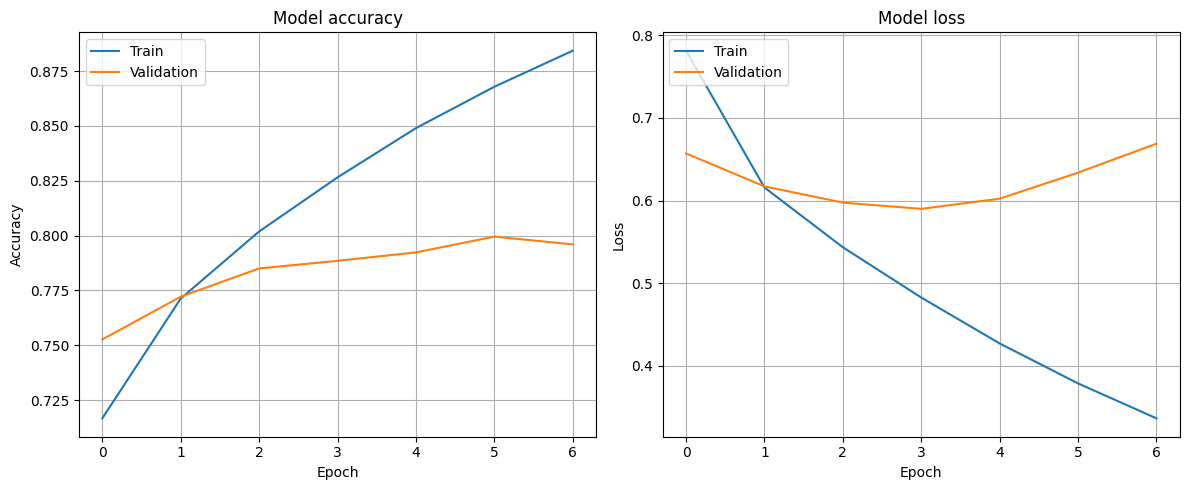

In [ ]:
# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.grid(True)

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.grid(True)

plt.tight_layout()
plt.show()